In [318]:
#installing required library 
import pandas as pd 
import numpy as np 


In [319]:
#importing data 
df = pd.read_csv('dataset/spam.csv',encoding = 'latin1' )

In [320]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
2595,spam,Sunshine Quiz Wkly Q! Win a top Sony DVD playe...,NaN,NaN,NaN
3793,ham,Short But Cute: \Be a good person,"but dont try to prove it..\"" .Gud noon....""",NaN,NaN
1124,ham,Aiyar sorry lor forgot 2 tell u...,NaN,NaN,NaN
492,ham,"Sorry,in meeting I'll call later",NaN,NaN,NaN
201,ham,Hello darlin ive finished college now so txt m...,NaN,NaN,NaN


In [321]:
df.shape

(5572, 5)

# data cleaning 

In [322]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [323]:
#dropping unwanted columns from the data...
df = df.drop(columns=(['Unnamed: 2','Unnamed: 3','Unnamed: 4']))

In [324]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   v1      5572 non-null   object
 1   v2      5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [325]:
df.sample(5)

,v1,v2
1892,spam,CALL 09090900040 & LISTEN TO EXTREME DIRTY LIV...
5289,ham,Hey! Congrats 2u2. id luv 2 but ive had 2 go h...
206,ham,"As I entered my cabin my PA said, '' Happy B'd..."
4537,ham,Dare i ask... Any luck with sorting out the car?
3664,ham,Ha... U jus ate honey ar? So sweet...


In [326]:
df.rename(columns = {'v1':'target', 'v2':'text'}, inplace =True)

In [327]:
df.sample(5)

,target,text
1144,ham,Really... I tot ur paper ended long ago... But...
3573,ham,Yeah sure I'll leave in a min
4239,ham,The LAY MAN! Just to let you know you are miss...
5398,ham,Hi. Hope you had a good day. Have a better night.
3104,ham,Or remind me in a few hrs.


In [328]:
from sklearn.preprocessing import LabelEncoder 
encoder = LabelEncoder()

In [329]:
#transforming the data
df['target']=encoder.fit_transform(df['target'])

In [330]:
df.sample(5)

,target,text
1172,0,Happy new years melody!
2483,0,Mm have some kanji dont eat anything heavy ok
1899,0,I love working from home :)
947,0,Hey i booked the kb on sat already... what oth...
4577,1,Urgent! call 09066350750 from your landline. Y...


In [331]:
#checking for null values...
df.isnull().sum()

target    0
text      0
dtype: int64

In [332]:
#checking for duplicates 
df.duplicated().sum()

403

In [333]:
#removing the duplicates 
df = df.drop_duplicates(keep="first")

In [334]:
#checking after duplicates has been dropped from the data 
df.duplicated().sum()

0

In [335]:
#checking the shapeof the data 
df.shape

(5169, 2)

# EDA

In [336]:
#lets count the value of the data 
df['target'].value_counts()

0    4516
1     653
Name: target, dtype: int64

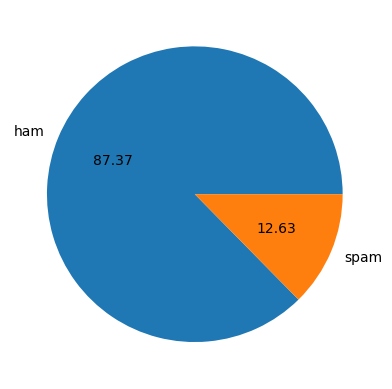

In [337]:
#drawing the pie chart for the dataset 
import matplotlib.pyplot as plt 
plt.pie(df['target'].value_counts(), labels =['ham', 'spam'], autopct= '%0.2f')
plt.show()

<BarContainer object of 2 artists>

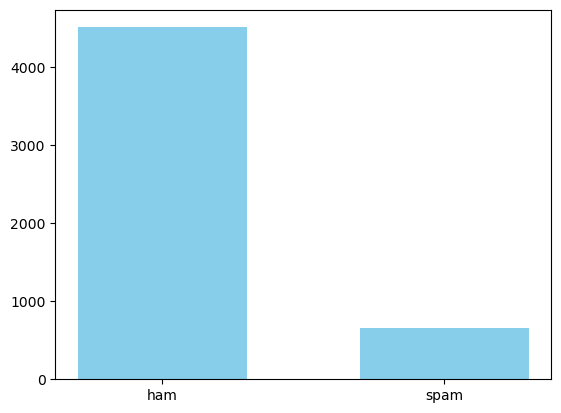

In [338]:
#lets plot the bargrph for the it 
plt.bar(['ham', 'spam'],df['target'].value_counts(), color='skyblue', width =0.6)

In [339]:
#importing nltk 
import nltk

In [340]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/santoshkhatri/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [341]:
#checking the length of the email and adding it to new column 
df['num_character']=df['text'].apply(len)

In [342]:
df.head()

,target,text,num_character
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [343]:
#counting the number of words in the email and storing in the new column 
df['num_words']=df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [344]:
df.head()

,target,text,num_character,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [345]:
#checking number of sentance used in every email 
df['num_sentance']=df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [346]:
df.head()

,target,text,num_character,num_words,num_sentance
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [347]:
df[['num_character','num_words','num_sentance']].describe()

,num_character,num_words,num_sentance
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.453279,1.947185
std,58.236293,13.324793,1.362406
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,28.000000


In [348]:
#checking for individual ham 
df[df['target']==0][['num_character','num_words','num_sentance']].describe()
    

,num_character,num_words,num_sentance
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.120903,1.799601
std,56.358207,13.493725,1.278465
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,28.000000


In [349]:
#describing data for spam
df[df['target']==1][['num_character','num_words','num_sentance']].describe()

,num_character,num_words,num_sentance
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.967841
std,30.137753,7.008418,1.483201
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,8.000000


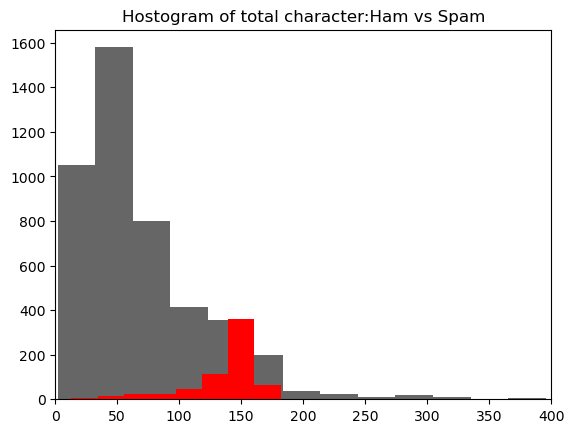

In [350]:
#drawing hiostogram from ham and spam 
plt.hist(df[df['target']==0]['num_character'],bins=30,alpha=0.6,color='black',label ='ham')
plt.hist(df[df['target']==1]['num_character'],color='red')
plt.title('Hostogram of total character:Ham vs Spam')
plt.xlim(0,400)
plt.show()

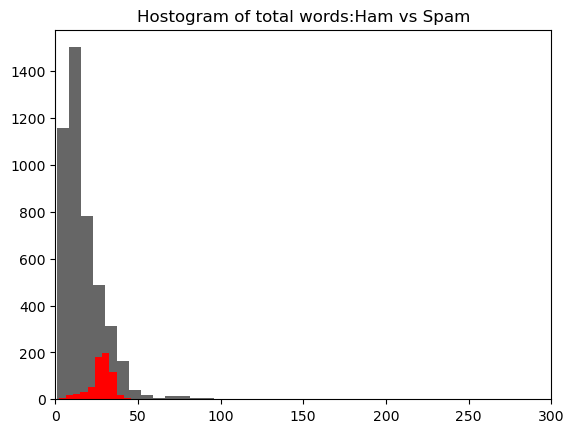

In [351]:
#drawing hiostogram from ham and spam for words 
plt.hist(df[df['target']==0]['num_words'],bins=30,alpha=0.6,color='black',label ='ham')
plt.hist(df[df['target']==1]['num_words'],color='red')
plt.title('Hostogram of total words:Ham vs Spam')
plt.xlim(0,300)
plt.show()

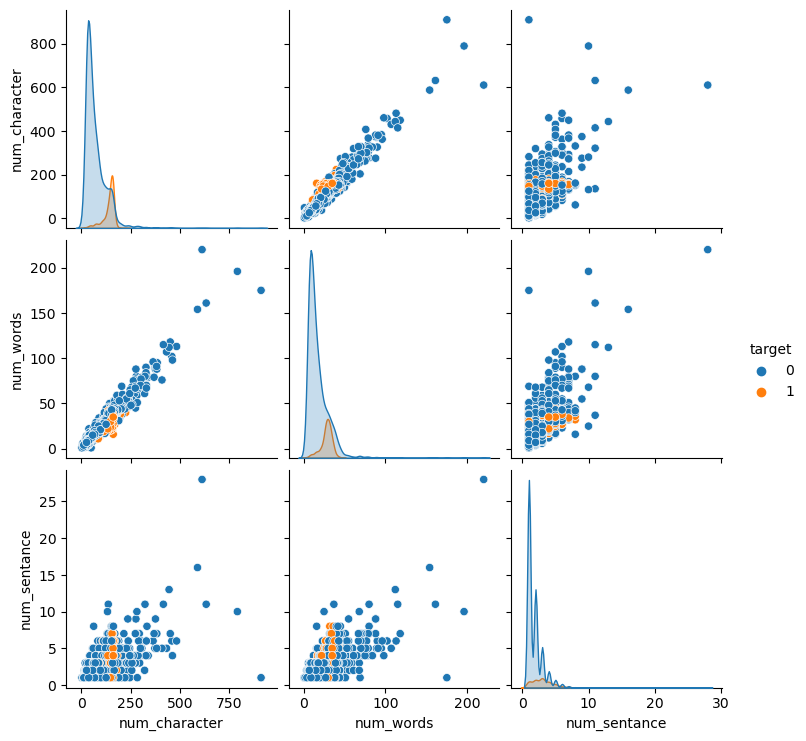

In [352]:
#checking its relation in pairplot 
import seaborn as sns 
sns.pairplot(df,hue="target")
plt.show()

/var/folders/vl/bzb4z1n52mv9g_f37flptljh0000gn/T/ipykernel_88363/1784379384.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df.corr(),annot = True)


<Axes: >

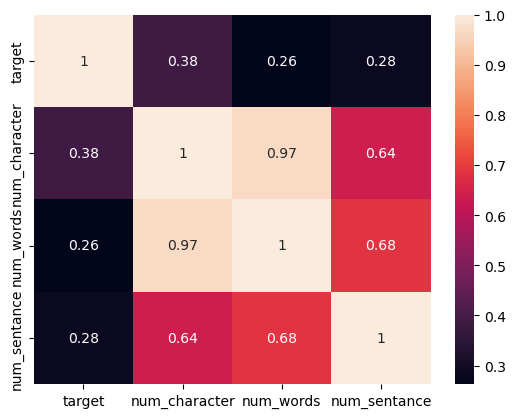

In [353]:
#checking correlation 
sns.heatmap(df.corr(),annot = True)

# data/text prepprocessing 
1.lowercase
2.tokenization
3.removing special character 
4.removing stop words and punctuation 
5.stemming/lemitization


In [354]:
##making function to text preprocessing 
#for checking the stopwords 
from nltk.corpus import stopwords 

import string 
from nltk.stem.porter import PorterStemmer 
ps = PorterStemmer()


def transform_text(text):
    text  = text.lower()  #converting text to lowercase 
    text = nltk.word_tokenize(text)
    
    y=[]
    for i in text:
        if i.isalnum():
            y.append(i)
    
    text = y[:]
    y.clear()
    for i in text:
        if i not in stopwords.words("english") and i not in string.punctuation:
            y.append(i)
    
    text = y[:]
    y.clear()
    
    for i in text:
        y.append(ps.stem(i))
    
    return " ".join(y)

In [355]:
df['transform_text']=df['text'].apply(transform_text)

In [356]:
df.head()

,target,text,num_character,num_words,num_sentance,transform_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [357]:
#making wordcloud 
from wordcloud import WordCloud
wc = WordCloud(width=1500, height =900, min_font_size = 10, background_color = "white")

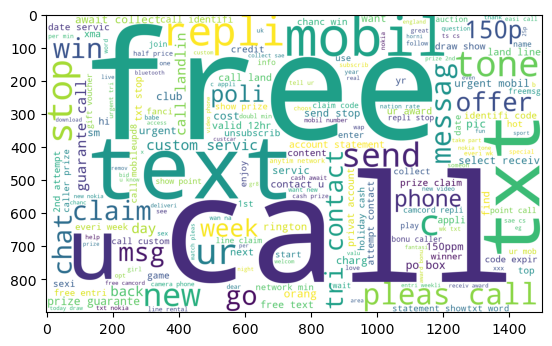

In [358]:
#generating spam wordcloud... 

spam_wc = wc.generate(df[df['target']==1]['transform_text'].str.cat(sep=" "))
plt.imshow(spam_wc)

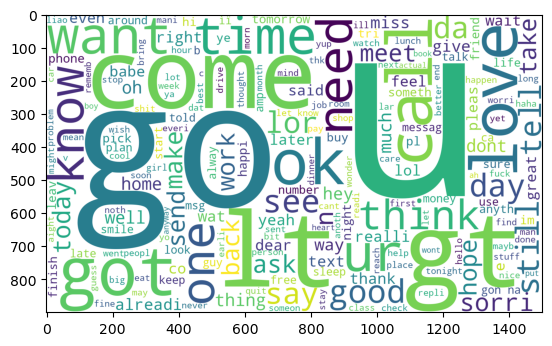

In [359]:
spam_wc = wc.generate(df[df['target']==0]['transform_text'].str.cat(sep=" "))
plt.imshow(spam_wc)

# Model building 


In [360]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer()

In [361]:
X = tfidf.fit_transform(df['transform_text']).toarray()

In [362]:
X.shape

(5169, 6708)

In [363]:
y = df['target'].values

In [364]:
y

array([0, 0, 1, ..., 0, 0, 0])

In [365]:
from sklearn.model_selection import train_test_split 

In [366]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size =0.2,random_state=2)

In [367]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix,precision_score,classification_report

In [368]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [369]:
#training model 
gnb.fit(X_train,y_train)
y_pred1=gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1,average='macro'))

0.8762088974854932
[[793 103]
 [ 25 113]]
0.7462929004799421


In [370]:
#training another model 
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2,average='macro'))

0.9593810444874274
[[896   0]
 [ 42  96]]
0.9776119402985075


In [371]:
#training another model 
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3,average='macro'))

0.9700193423597679
[[893   3]
 [ 28 110]]
0.9715247950957501


In [372]:
#importing few other model for better learning 
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB 
from sklearn.tree import DecisionTreeClassifier 
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.ensemble import RandomForestClassifier 
from sklearn.ensemble import AdaBoostClassifier 
from sklearn.ensemble import BaggingClassifier 
from sklearn.ensemble import ExtraTreesClassifier 
from sklearn.ensemble import GradientBoostingClassifier 
from xgboost import XGBClassifier 

In [378]:
#making object of all the models accordingly 
lr = LogisticRegression()
svc = SVC(kernel ='sigmoid')
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth =5)
##knc = KNeighborsClassifier()
rfc = RandomForestClassifier(n_estimators = 50, random_state = 2)
abc = AdaBoostClassifier(n_estimators = 50, random_state = 2)
bc = BaggingClassifier(n_estimators = 50, random_state = 2)
etc = ExtraTreesClassifier(n_estimators = 50, random_state = 2)
rbc =GradientBoostingClassifier(n_estimators = 50, random_state = 2)
xbc = XGBClassifier(n_estimators = 50, random_state = 2)

In [379]:
#making dictionary of machine learning algorithm 
clfs = {
    'LR':lr,
    'SVC':svc,
    'MNB':mnb,
    'DTC':dtc,
    ##'KNC':knc,
    'RFC':rfc,
    'ABC':abc,
    'BC':bc,
    'ETC':etc,
    'RBC':rbc,
    'XBC':xbc
}

In [380]:
def train_classifier(clf,X_train, y_train,X_test, y_test):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    accuracy=accuracy_score(y_test,y_pred)
    precision=precision_score(y_test,y_pred)
    
    return accuracy,precision
    

In [381]:
train_classifier(svc,X_train,y_train, X_test,y_test)

(0.9729206963249516, 0.9741379310344828)

In [ ]:
accuracy_scores =[]
precision_scores =[]

for name , clf in clfs.items():
    current_accuracy, current_precision = train_classifier(clf, X_train,y_train,X_test, y_test)
    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  LR
Accuracy -  0.9468085106382979
Precision -  0.9882352941176471
For  SVC
Accuracy -  0.9729206963249516
Precision -  0.9741379310344828
For  MNB
Accuracy -  0.9593810444874274
Precision -  1.0
For  DTC
Accuracy -  0.9352030947775629
Precision -  0.8380952380952381
For  RFC
Accuracy -  0.9738878143133463
Precision -  1.0
For  ABC
Accuracy -  0.9613152804642167
Precision -  0.9454545454545454


In [ ]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)